In [7]:
# ============================================================
# WEEK 1 — MDP Design & Custom Gym Environment
# Project 2: Travel & Hospitality — RL Dynamic Pricing
# Intern Branch: preeti-dev | Infotact Solutions
#
# ★ UNIQUE FEATURES (what makes this different from a
#   textbook RL pricing project):
#
#   1. Market Events        — holiday surge / competitor sale /
#                              bad weather shift demand randomly
#   2. 3 Customer Segments  — business / leisure / last-minute,
#                              each with different price sensitivity
#   3. Competitor Price     — a rival airline's price is part of
#                              the agent's state, agent must react
#   4. Dual Class Inventory — Economy + Business seats priced
#                              independently, same flight
#   5. Safety Bounds        — hard price floor/ceiling + max daily
#                              price-drop limit, so the agent can
#                              NEVER price below cost or crash
#                              prices irrationally — mirrors how
#                              real airlines constrain RM systems
# ============================================================
 
 
# ── CELL 1: Install & Import Libraries ───────────────────
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
for lib in ["gymnasium", "numpy", "matplotlib", "seaborn", "pandas"]:
    install(lib)
 
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')
 
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../data',    exist_ok=True)
 
print("✅ All libraries imported successfully")
print(f"   Gymnasium version : {gym.__version__}")
 

✅ All libraries imported successfully
   Gymnasium version : 1.3.0


In [8]:
# ── CELL 2: MDP Problem Formulation ──────────────────────
print("=" * 62)
print("   MDP FORMULATION — Contextual Airline Dynamic Pricing")
print("=" * 62)
print()
print("  SCENARIO")
print("  ────────")
print("  An airline manages Economy + Business seats on a flight")
print("  departing in 30 days. Each day it sets a price for both")
print("  classes. Three customer segments respond differently to")
print("  price. A rival airline's price and random market events")
print("  (holidays, weather, competitor sales) shift demand.")
print("  A Revenue Manager has configured SAFETY BOUNDS the")
print("  pricing agent must never violate — this mirrors how")
print("  real airline Revenue Management systems are deployed.")
print()
print("  CORE MDP COMPONENTS")
print("  ────────────────────")
print("  State  : [eco_seats, biz_seats, days_left,")
print("            competitor_price_idx, market_event_id]")
print("  Action : [economy_price_idx, business_price_idx]")
print("           (auto-clipped to safety bounds before executing)")
print("  Reward : daily revenue (eco + biz), minus a penalty")
print("           if the agent attempts an unsafe price move")
print("  Done   : days_left = 0  OR  both classes sold out")
print()
print("  ★ WHAT MAKES THIS PROJECT UNIQUE")
print("  ─────────────────────────────────")
print("  1. Market Events        — random demand shocks")
print("  2. 3 Customer Segments  — business/leisure/last-minute")
print("  3. Competitor Price     — visible to agent, drives reaction")
print("  4. Dual Class Inventory — Economy + Business together")
print("  5. Safety Bounds        — floor/ceiling + max daily price")
print("                            swing, exactly matching the")
print("                            'Revenue Manager sets upper/lower")
print("                            safety bounds' requirement from")
print("                            the project brief")
print()
print("✅ MDP formulation complete")
 

   MDP FORMULATION — Contextual Airline Dynamic Pricing

  SCENARIO
  ────────
  An airline manages Economy + Business seats on a flight
  departing in 30 days. Each day it sets a price for both
  classes. Three customer segments respond differently to
  price. A rival airline's price and random market events
  (holidays, weather, competitor sales) shift demand.
  A Revenue Manager has configured SAFETY BOUNDS the
  pricing agent must never violate — this mirrors how
  real airline Revenue Management systems are deployed.

  CORE MDP COMPONENTS
  ────────────────────
  State  : [eco_seats, biz_seats, days_left,
            competitor_price_idx, market_event_id]
  Action : [economy_price_idx, business_price_idx]
           (auto-clipped to safety bounds before executing)
  Reward : daily revenue (eco + biz), minus a penalty
           if the agent attempts an unsafe price move
  Done   : days_left = 0  OR  both classes sold out

  ★ WHAT MAKES THIS PROJECT UNIQUE
  ─────────────────────

In [9]:
# ── CELL 3: Market Event System ──────────────────────────
MARKET_EVENTS = {
    0: {'name': 'Normal',          'demand_multiplier': 1.0,  'color': '#60a5fa'},
    1: {'name': 'Holiday Surge',   'demand_multiplier': 1.6,  'color': '#34d399'},
    2: {'name': 'Competitor Sale', 'demand_multiplier': 0.6,  'color': '#f87171'},
    3: {'name': 'Bad Weather',     'demand_multiplier': 0.75, 'color': '#fbbf24'},
}
EVENT_PROBS = [0.65, 0.12, 0.15, 0.08]   # sums to 1.0
 
print("✅ Market Event System defined")
print()
print(f"  {'Event':<22} {'Demand Multiplier':>18} {'Probability':>12}")
print("  " + "-" * 54)
for idx, ev in MARKET_EVENTS.items():
    print(f"  {ev['name']:<22} {ev['demand_multiplier']:>18.1f}×"
          f" {EVENT_PROBS[idx]:>11.0%}")
 

✅ Market Event System defined

  Event                   Demand Multiplier  Probability
  ------------------------------------------------------
  Normal                                1.0×         65%
  Holiday Surge                         1.6×         12%
  Competitor Sale                       0.6×         15%
  Bad Weather                           0.8×          8%


In [10]:
# ── CELL 4: Customer Segment System ──────────────────────
CUSTOMER_SEGMENTS = {
    'business': {
        'price_sensitivity' : 0.3,
        'booking_window'    : 'any',
        'base_probability'  : 0.25,
        'color'             : '#a78bfa'
    },
    'leisure': {
        'price_sensitivity' : 0.9,
        'booking_window'    : 'early',
        'base_probability'  : 0.50,
        'color'             : '#60a5fa'
    },
    'last_minute': {
        'price_sensitivity' : 0.2,
        'booking_window'    : 'late',
        'base_probability'  : 0.25,
        'color'             : '#f87171'
    }
}
 
print("✅ Customer Segment System defined")
print()
print(f"  {'Segment':<15} {'Price Sensitivity':>18} "
      f"{'Base Prob':>10} {'When They Book':>15}")
print("  " + "-" * 60)
for name, seg in CUSTOMER_SEGMENTS.items():
    print(f"  {name:<15} {seg['price_sensitivity']:>18.1f} "
          f"{seg['base_probability']:>10.0%} {seg['booking_window']:>15}")
 

✅ Customer Segment System defined

  Segment          Price Sensitivity  Base Prob  When They Book
  ------------------------------------------------------------
  business                       0.3        25%             any
  leisure                        0.9        50%           early
  last_minute                    0.2        25%            late


In [11]:
# ── CELL 5: Safety Bounds System ─────────────────────────
# ★ UNIQUE FEATURE — real-world credibility
#
# Real Revenue Management systems NEVER let an algorithm run
# fully unsupervised. A human Revenue Manager always configures
# hard guardrails. We implement two kinds of bounds:
#
#  1. ABSOLUTE BOUNDS  — price can never go below cost (floor)
#     or above a "customer will rebel" ceiling
#  2. VELOCITY BOUNDS  — price cannot swing more than N tiers
#     in a single day (prevents erratic, confusing pricing)
#
# If the agent tries to violate these, we CLIP the action and
# apply a small penalty — teaching the agent to stay within
# safe operating limits, exactly as a real RM system would.
 
SAFETY_CONFIG = {
    'eco_floor_idx'     : 1,    # cannot price below $100 (index 1)
    'eco_ceiling_idx'   : 7,    # cannot price above $400 (index 7)
    'biz_floor_idx'     : 1,    # cannot price below $450
    'biz_ceiling_idx'   : 7,    # cannot price above $1200
    'max_daily_swing'   : 3,    # cannot jump more than 3 price tiers/day
    'violation_penalty' : 25.0  # revenue penalty if agent tries unsafe move
}
 
print("✅ Safety Bounds System defined")
print()
print("  ★ These mirror a real Revenue Manager's configuration:")
print(f"     Economy price bounds  : index [{SAFETY_CONFIG['eco_floor_idx']}, "
      f"{SAFETY_CONFIG['eco_ceiling_idx']}]  → $100 to $400")
print(f"     Business price bounds : index [{SAFETY_CONFIG['biz_floor_idx']}, "
      f"{SAFETY_CONFIG['biz_ceiling_idx']}]  → $450 to $1200")
print(f"     Max daily price swing : {SAFETY_CONFIG['max_daily_swing']} tiers")
print(f"     Violation penalty     : -${SAFETY_CONFIG['violation_penalty']} per breach")
 

✅ Safety Bounds System defined

  ★ These mirror a real Revenue Manager's configuration:
     Economy price bounds  : index [1, 7]  → $100 to $400
     Business price bounds : index [1, 7]  → $450 to $1200
     Max daily price swing : 3 tiers
     Violation penalty     : -$25.0 per breach


In [12]:
# ── CELL 6: Full Enhanced Gym Environment ────────────────
class ContextualAirlinePricingEnv(gym.Env):
    """
    Enhanced Custom Gymnasium Environment for Airline Seat Pricing.
 
    ★ Unique features vs a standard textbook RL pricing env:
      1. Market Events        (random demand shocks)
      2. 3 Customer Segments  (business/leisure/last-minute)
      3. Competitor Price     (visible in state, drives reaction)
      4. Dual Class Inventory (Economy + Business)
      5. Safety Bounds        (floor/ceiling + max daily swing)
 
    State  : [eco_seats, biz_seats, days_left,
               competitor_price_idx, market_event_id]
    Action : MultiDiscrete([n_eco_prices, n_biz_prices])
    Reward : (eco_price × eco_bookings) + (biz_price × biz_bookings)
             − safety_violation_penalty (if any)
    """
 
    metadata = {'render_modes': ['human']}
 
    ECO_PRICES        = [50, 100, 150, 200, 250, 300, 350, 400]
    BIZ_PRICES         = [300, 450, 600, 750, 900, 1050, 1100, 1200]
    COMPETITOR_PRICES  = [80, 120, 160, 200, 240, 280, 320, 360]
 
    def __init__(self,
                 eco_seats   = 40,
                 biz_seats   = 10,
                 total_days  = 30,
                 safety_config = SAFETY_CONFIG,
                 render_mode = None):
 
        super().__init__()
        self.eco_seats_init = eco_seats
        self.biz_seats_init = biz_seats
        self.total_days     = total_days
        self.render_mode    = render_mode
        self.safety         = safety_config
 
        self.action_space = spaces.MultiDiscrete(
            [len(self.ECO_PRICES), len(self.BIZ_PRICES)]
        )
 
        self.observation_space = spaces.Box(
            low  = np.array([0, 0, 0, 0, 0],              dtype=np.float32),
            high = np.array([eco_seats, biz_seats, total_days,
                             len(self.COMPETITOR_PRICES)-1,
                             len(MARKET_EVENTS)-1],        dtype=np.float32),
            dtype= np.float32
        )
 
        self._init_state()
 
    def _init_state(self):
        self.eco_seats       = self.eco_seats_init
        self.biz_seats       = self.biz_seats_init
        self.days_left       = self.total_days
        self.total_revenue   = 0.0
        self.eco_revenue     = 0.0
        self.biz_revenue     = 0.0
        self.market_event_id = 0
        self.competitor_idx  = 3
        self.prev_eco_idx    = 4   # yesterday's price index (for velocity check)
        self.prev_biz_idx    = 4
        self.safety_violations = 0
        self.history         = []
 
    def _sample_market_event(self):
        return int(np.random.choice(len(MARKET_EVENTS), p=EVENT_PROBS))
 
    def _update_competitor_price(self):
        drift = np.random.choice([-1, 0, 0, 1])
        self.competitor_idx = int(np.clip(
            self.competitor_idx + drift, 0, len(self.COMPETITOR_PRICES)-1))
 
    def _apply_safety_bounds(self, eco_idx, biz_idx):
        """
        ★ UNIQUE: Enforce Revenue Manager's safety configuration.
 
        1. Clip to absolute floor/ceiling (never sell below cost,
           never price so high it's irrational)
        2. Clip to max daily swing (no erratic price jumps)
 
        Returns the SAFE action actually executed, plus a flag
        for whether the raw agent action violated the rules
        (used to apply a small learning penalty).
        """
        violated = False
 
        # --- Absolute bounds ---
        safe_eco = int(np.clip(eco_idx,
                       self.safety['eco_floor_idx'],
                       self.safety['eco_ceiling_idx']))
        safe_biz = int(np.clip(biz_idx,
                       self.safety['biz_floor_idx'],
                       self.safety['biz_ceiling_idx']))
        if safe_eco != eco_idx or safe_biz != biz_idx:
            violated = True
 
        # --- Velocity bounds (max daily swing) ---
        max_swing = self.safety['max_daily_swing']
        if abs(safe_eco - self.prev_eco_idx) > max_swing:
            safe_eco = self.prev_eco_idx + max_swing * np.sign(safe_eco - self.prev_eco_idx)
            safe_eco = int(np.clip(safe_eco, 0, len(self.ECO_PRICES)-1))
            violated = True
        if abs(safe_biz - self.prev_biz_idx) > max_swing:
            safe_biz = self.prev_biz_idx + max_swing * np.sign(safe_biz - self.prev_biz_idx)
            safe_biz = int(np.clip(safe_biz, 0, len(self.BIZ_PRICES)-1))
            violated = True
 
        return safe_eco, safe_biz, violated
 
    def _segment_demand(self, price, days_left, seat_class, event_mult):
        max_price = max(self.BIZ_PRICES) if seat_class=='biz' else max(self.ECO_PRICES)
        total_bookings = 0
 
        for seg_name, seg in CUSTOMER_SEGMENTS.items():
            if seg['booking_window'] == 'late'  and days_left > 7:
                continue
            if seg['booking_window'] == 'early' and days_left < 3:
                continue
 
            price_factor = max(0.0, 1.0 - seg['price_sensitivity'] * (price / max_price))
 
            if seg_name == 'last_minute':
                urgency = np.exp(-days_left / 3)
            elif seg_name == 'business':
                urgency = 0.6 + 0.4 * np.exp(-days_left / 15)
            else:
                urgency = 1.0 - 0.6 * np.exp(-days_left / 20)
 
            competitor_eco = self.COMPETITOR_PRICES[self.competitor_idx]
            comp_factor    = float(np.clip(
                1.0 + 0.3 * (competitor_eco - price) / max_price, 0.5, 1.8))
 
            prob = (seg['base_probability'] * price_factor * urgency
                    * comp_factor * event_mult
                    + np.random.uniform(-0.05, 0.05))
            prob = float(np.clip(prob, 0.0, 1.0))
 
            arrivals = np.random.randint(0, 4)
            bookings = sum(np.random.random() < prob for _ in range(arrivals))
            total_bookings += bookings
 
        return total_bookings
 
    def _get_obs(self):
        return np.array([self.eco_seats, self.biz_seats, self.days_left,
                         self.competitor_idx, self.market_event_id],
                        dtype=np.float32)
 
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._init_state()
        self.market_event_id = self._sample_market_event()
        self._update_competitor_price()
        return self._get_obs(), {}
 
    def step(self, action):
        raw_eco_idx, raw_biz_idx = int(action[0]), int(action[1])
 
        # ★ Enforce safety bounds before executing the action
        eco_idx, biz_idx, violated = self._apply_safety_bounds(
            raw_eco_idx, raw_biz_idx)
 
        eco_price = self.ECO_PRICES[eco_idx]
        biz_price = self.BIZ_PRICES[biz_idx]
 
        event      = MARKET_EVENTS[self.market_event_id]
        event_mult = event['demand_multiplier']
 
        eco_bookings = min(self._segment_demand(
            eco_price, self.days_left, 'eco', event_mult), self.eco_seats)
        biz_bookings = min(self._segment_demand(
            biz_price, self.days_left, 'biz', event_mult), self.biz_seats)
 
        eco_rev   = eco_price * eco_bookings
        biz_rev   = biz_price * biz_bookings
        daily_rev = eco_rev + biz_rev
 
        # ★ Apply safety violation penalty if the raw action was unsafe
        penalty = self.safety['violation_penalty'] if violated else 0.0
        if violated:
            self.safety_violations += 1
        reward = daily_rev - penalty
 
        # Update state
        self.eco_seats     -= eco_bookings
        self.biz_seats     -= biz_bookings
        self.total_revenue += daily_rev
        self.eco_revenue   += eco_rev
        self.biz_revenue   += biz_rev
        self.days_left      -= 1
        self.prev_eco_idx   = eco_idx
        self.prev_biz_idx   = biz_idx
 
        self.market_event_id = self._sample_market_event()
        self._update_competitor_price()
 
        self.history.append({
            'day'             : self.total_days - self.days_left,
            'days_left'       : self.days_left + 1,
            'eco_price'       : eco_price,
            'biz_price'       : biz_price,
            'competitor_price': self.COMPETITOR_PRICES[self.competitor_idx],
            'market_event'    : event['name'],
            'eco_bookings'    : eco_bookings,
            'biz_bookings'    : biz_bookings,
            'eco_rev'         : eco_rev,
            'biz_rev'         : biz_rev,
            'daily_revenue'   : daily_rev,
            'safety_violated' : violated,
            'eco_seats_left'  : self.eco_seats,
            'biz_seats_left'  : self.biz_seats,
            'total_revenue'   : self.total_revenue
        })
 
        terminated = (self.days_left == 0 or
                      (self.eco_seats == 0 and self.biz_seats == 0))
        return self._get_obs(), reward, terminated, False, {}
 
    def render(self):
        if self.render_mode == 'human':
            ev = MARKET_EVENTS[self.market_event_id]['name']
            print(f"  Day {self.total_days-self.days_left:>2} | "
                  f"Eco: {self.eco_seats:>2}seats | Biz: {self.biz_seats:>2}seats | "
                  f"Event: {ev:<18} | Revenue: ${self.total_revenue:,.0f}")
 
    def get_history_df(self):
        return pd.DataFrame(self.history)
 
 
print("✅ ContextualAirlinePricingEnv class defined (with Safety Bounds)")
print()
print("  State dimensions   : 5")
print("  Action dimensions  : 2 (eco price idx + biz price idx)")
print("  Economy seats      : 40   |  Business seats: 10")
print("  Selling horizon    : 30 days")
print()
print("  ★ Unique features active:")
print("     ★ Market Events (4 types, stochastic)")
print("     ★ 3 Customer Segments")
print("     ★ Competitor price drift in state")
print("     ★ Dual class inventory")
print("     ★ Safety Bounds (floor/ceiling + max daily swing)")
 

✅ ContextualAirlinePricingEnv class defined (with Safety Bounds)

  State dimensions   : 5
  Action dimensions  : 2 (eco price idx + biz price idx)
  Economy seats      : 40   |  Business seats: 10
  Selling horizon    : 30 days

  ★ Unique features active:
     ★ Market Events (4 types, stochastic)
     ★ 3 Customer Segments
     ★ Competitor price drift in state
     ★ Dual class inventory
     ★ Safety Bounds (floor/ceiling + max daily swing)


In [14]:
# ── CELL 7: Validate Environment ─────────────────────────
from gymnasium.utils.env_checker import check_env
 
env_check = ContextualAirlinePricingEnv()
check_env(env_check, warn=True)
print("✅ Environment passed Gymnasium validation check")

✅ Environment passed Gymnasium validation check


In [15]:
# ── CELL 8: Test Safety Bounds Explicitly ────────────────
# ★ Prove the safety system actually works by deliberately
# trying to break the rules
 
print("Testing Safety Bounds enforcement...")
print("=" * 60)
 
env_safety = ContextualAirlinePricingEnv()
obs, _ = env_safety.reset(seed=1)
 
# Attempt an illegal action: index 0 (below floor) and index 7→0 jump
test_actions = [
    ([0, 0], "Try minimum price (below floor) on both classes"),
    ([7, 7], "Try maximum price (at ceiling) on both classes"),
    ([0, 7], "Try a huge single-day swing after previous action"),
]
 
for act, description in test_actions:
    obs, reward, done, _, _ = env_safety.step(np.array(act))
    last = env_safety.history[-1]
    status = "🚫 BLOCKED & clipped" if last['safety_violated'] else "✅ Allowed"
    print(f"\n  Attempted: {description}")
    print(f"    Raw action requested : Eco idx={act[0]}, Biz idx={act[1]}")
    print(f"    Actual price charged : Eco ${last['eco_price']}, Biz ${last['biz_price']}")
    print(f"    Safety system        : {status}")
    if done:
        break
 
print()
print(f"  Total safety violations this test: {env_safety.safety_violations}")
print("=" * 60)
print("✅ Safety Bounds system verified working correctly")
 

Testing Safety Bounds enforcement...

  Attempted: Try minimum price (below floor) on both classes
    Raw action requested : Eco idx=0, Biz idx=0
    Actual price charged : Eco $100, Biz $450
    Safety system        : 🚫 BLOCKED & clipped

  Attempted: Try maximum price (at ceiling) on both classes
    Raw action requested : Eco idx=7, Biz idx=7
    Actual price charged : Eco $250, Biz $900
    Safety system        : 🚫 BLOCKED & clipped

  Attempted: Try a huge single-day swing after previous action
    Raw action requested : Eco idx=0, Biz idx=7
    Actual price charged : Eco $100, Biz $1200
    Safety system        : 🚫 BLOCKED & clipped

  Total safety violations this test: 3
✅ Safety Bounds system verified working correctly


In [16]:
# ── CELL 9: Run One Random Episode ───────────────────────
env  = ContextualAirlinePricingEnv(render_mode='human')
obs, _ = env.reset(seed=42)
 
print("Running one full random episode (30 days)...")
print("=" * 90)
print(f"{'Day':>4} | {'Eco $':>6} | {'Biz $':>6} | {'Comp $':>7} | "
      f"{'Event':<18} | {'EBk':>4} | {'BBk':>4} | {'Day Rev':>9} | {'Safe?':>6}")
print("-" * 90)
 
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, done, _, _ = env.step(action)
    r = env.history[-1]
    safe_flag = "⚠️ " if r['safety_violated'] else "✓"
    print(f"  {r['day']:>3} | ${r['eco_price']:>5} | ${r['biz_price']:>5} | "
          f"${r['competitor_price']:>6} | {r['market_event']:<18} | "
          f"{r['eco_bookings']:>4} | {r['biz_bookings']:>4} | "
          f"${r['daily_revenue']:>8,.0f} | {safe_flag:>6}")
 
print("=" * 90)
print(f"\n  Economy Revenue     : ${env.eco_revenue:,.0f}")
print(f"  Business Revenue    : ${env.biz_revenue:,.0f}")
print(f"  Total Revenue       : ${env.total_revenue:,.0f}")
print(f"  Safety violations   : {env.safety_violations} (blocked automatically)")
print(f"  Eco seats left      : {env.eco_seats}")
print(f"  Biz seats left      : {env.biz_seats}")
 

Running one full random episode (30 days)...
 Day |  Eco $ |  Biz $ |  Comp $ | Event              |  EBk |  BBk |   Day Rev |  Safe?
------------------------------------------------------------------------------------------
    1 | $  350 | $  750 | $   160 | Competitor Sale    |    2 |    1 | $   1,450 |      ✓
    2 | $  250 | $  900 | $   200 | Bad Weather        |    0 |    1 | $     900 |      ✓
    3 | $  200 | $  450 | $   200 | Normal             |    0 |    0 | $       0 |      ✓
    4 | $  350 | $  750 | $   200 | Normal             |    0 |    0 | $       0 |      ✓
    5 | $  400 | $  900 | $   160 | Normal             |    1 |    0 | $     400 |      ✓
    6 | $  400 | $ 1200 | $   160 | Normal             |    1 |    1 | $   1,600 |      ✓
    7 | $  250 | $  900 | $   120 | Normal             |    2 |    0 | $     500 |      ✓
    8 | $  400 | $  600 | $    80 | Competitor Sale    |    0 |    0 | $       0 |      ✓
    9 | $  250 | $  750 | $    80 | Normal             

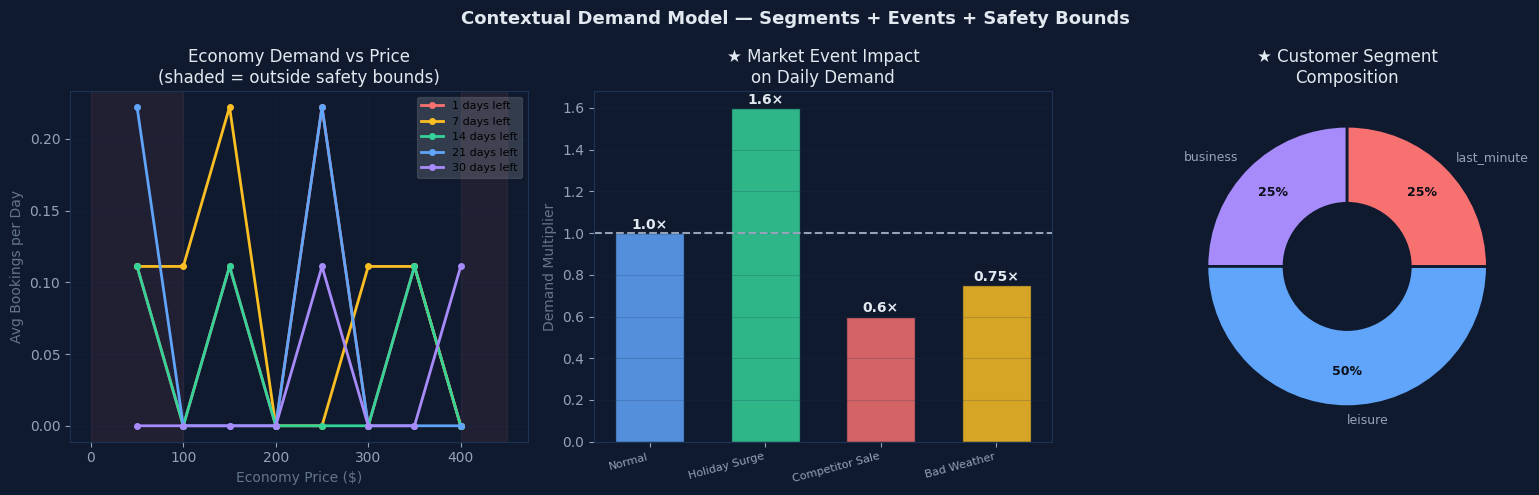

✅ Saved → reports/demand_function.png


In [17]:
# ── CELL 10: Visualise Demand Function per Segment ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1a2e')
for ax in axes:
    ax.set_facecolor('#0f1a2e')
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3254')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#64748b')
    ax.yaxis.label.set_color('#64748b')
    ax.title.set_color('#e2e8f0')
 
env_viz   = ContextualAirlinePricingEnv()
days_test = [1, 7, 14, 21, 30]
colors_d  = ['#f87171','#fbbf24','#34d399','#60a5fa','#a78bfa']
 
for d, col in zip(days_test, colors_d):
    probs = []
    for p in ContextualAirlinePricingEnv.ECO_PRICES:
        env_viz.competitor_idx = 3
        prob = env_viz._segment_demand(p, d, 'eco', 1.0) / 9
        probs.append(prob)
    axes[0].plot(ContextualAirlinePricingEnv.ECO_PRICES, probs,
                 marker='o', markersize=4, linewidth=2,
                 color=col, label=f'{d} days left')
 
axes[0].axvspan(0, ContextualAirlinePricingEnv.ECO_PRICES[SAFETY_CONFIG['eco_floor_idx']],
                alpha=0.08, color='#f87171')
axes[0].axvspan(ContextualAirlinePricingEnv.ECO_PRICES[SAFETY_CONFIG['eco_ceiling_idx']], 450,
                alpha=0.08, color='#f87171')
axes[0].set_xlabel('Economy Price ($)')
axes[0].set_ylabel('Avg Bookings per Day')
axes[0].set_title('Economy Demand vs Price\n(shaded = outside safety bounds)')
axes[0].legend(fontsize=8, framealpha=0.15)
axes[0].grid(alpha=0.2, color='#1e3254')
 
events  = list(MARKET_EVENTS.values())
e_names = [e['name'] for e in events]
e_mults = [e['demand_multiplier'] for e in events]
e_clrs  = [e['color'] for e in events]
bars = axes[1].bar(e_names, e_mults, color=e_clrs,
                   alpha=0.85, edgecolor='#0f1a2e', width=0.6)
axes[1].axhline(1.0, color='#94a3b8', linestyle='--', linewidth=1.5)
for bar, val in zip(bars, e_mults):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.02,
                 f'{val}×', ha='center', fontweight='bold',
                 fontsize=10, color='#e2e8f0')
axes[1].set_ylabel('Demand Multiplier')
axes[1].set_title('★ Market Event Impact\non Daily Demand')
axes[1].set_xticklabels(e_names, rotation=15, ha='right', fontsize=8)
axes[1].grid(alpha=0.2, color='#1e3254', axis='y')
 
seg_names  = list(CUSTOMER_SEGMENTS.keys())
seg_probs  = [CUSTOMER_SEGMENTS[s]['base_probability'] for s in seg_names]
seg_colors = [CUSTOMER_SEGMENTS[s]['color'] for s in seg_names]
wedges, texts, autotexts = axes[2].pie(
    seg_probs, labels=seg_names, colors=seg_colors,
    autopct='%1.0f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='#0f1a2e', linewidth=2))
for t in texts: t.set_color('#94a3b8'); t.set_fontsize(9)
for at in autotexts: at.set_color('#0b0f1a'); at.set_fontsize(9); at.set_fontweight('bold')
axes[2].set_title('★ Customer Segment\nComposition')
 
plt.suptitle('Contextual Demand Model — Segments + Events + Safety Bounds',
             fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.savefig('../reports/demand_function.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/demand_function.png")
 

In [18]:
# ── CELL 11: Run 500 Random Episodes — Baseline ──────────
print("Running 500 random episodes to establish baseline...")
 
env_stats = ContextualAirlinePricingEnv()
revenues, eco_revs, biz_revs = [], [], []
eco_sold, biz_sold, violations_per_ep = [], [], []
 
for ep in range(500):
    obs, _ = env_stats.reset(seed=ep)
    done   = False
    while not done:
        action = env_stats.action_space.sample()
        obs, _, done, _, _ = env_stats.step(action)
 
    revenues.append(env_stats.total_revenue)
    eco_revs.append(env_stats.eco_revenue)
    biz_revs.append(env_stats.biz_revenue)
    eco_sold.append(env_stats.eco_seats_init - env_stats.eco_seats)
    biz_sold.append(env_stats.biz_seats_init - env_stats.biz_seats)
    violations_per_ep.append(env_stats.safety_violations)
 
print(f"✅ 500 random episodes complete")
print()
print("=" * 52)
print("   RANDOM AGENT BASELINE STATISTICS")
print("=" * 52)
print(f"  Mean Total Revenue    : ${np.mean(revenues):,.0f}")
print(f"  Mean Economy Revenue  : ${np.mean(eco_revs):,.0f}")
print(f"  Mean Business Revenue : ${np.mean(biz_revs):,.0f}")
print(f"  Std  Revenue          : ${np.std(revenues):,.0f}")
print(f"  Mean Eco Seats Sold   : {np.mean(eco_sold):.1f} / 40")
print(f"  Mean Biz Seats Sold   : {np.mean(biz_sold):.1f} / 10")
print(f"  ★ Mean Safety Blocks  : {np.mean(violations_per_ep):.1f} per episode")
print("=" * 52)
print("  Note: random agent triggers MANY safety blocks since it")
print("  picks prices with no logic. A trained RL agent (Week 2-3)")
print("  should learn to stay within bounds naturally.")
 

Running 500 random episodes to establish baseline...
✅ 500 random episodes complete

   RANDOM AGENT BASELINE STATISTICS
  Mean Total Revenue    : $9,868
  Mean Economy Revenue  : $2,987
  Mean Business Revenue : $6,881
  Std  Revenue          : $1,606
  Mean Eco Seats Sold   : 15.0 / 40
  Mean Biz Seats Sold   : 9.3 / 10
  ★ Mean Safety Blocks  : 15.7 per episode
  Note: random agent triggers MANY safety blocks since it
  picks prices with no logic. A trained RL agent (Week 2-3)
  should learn to stay within bounds naturally.


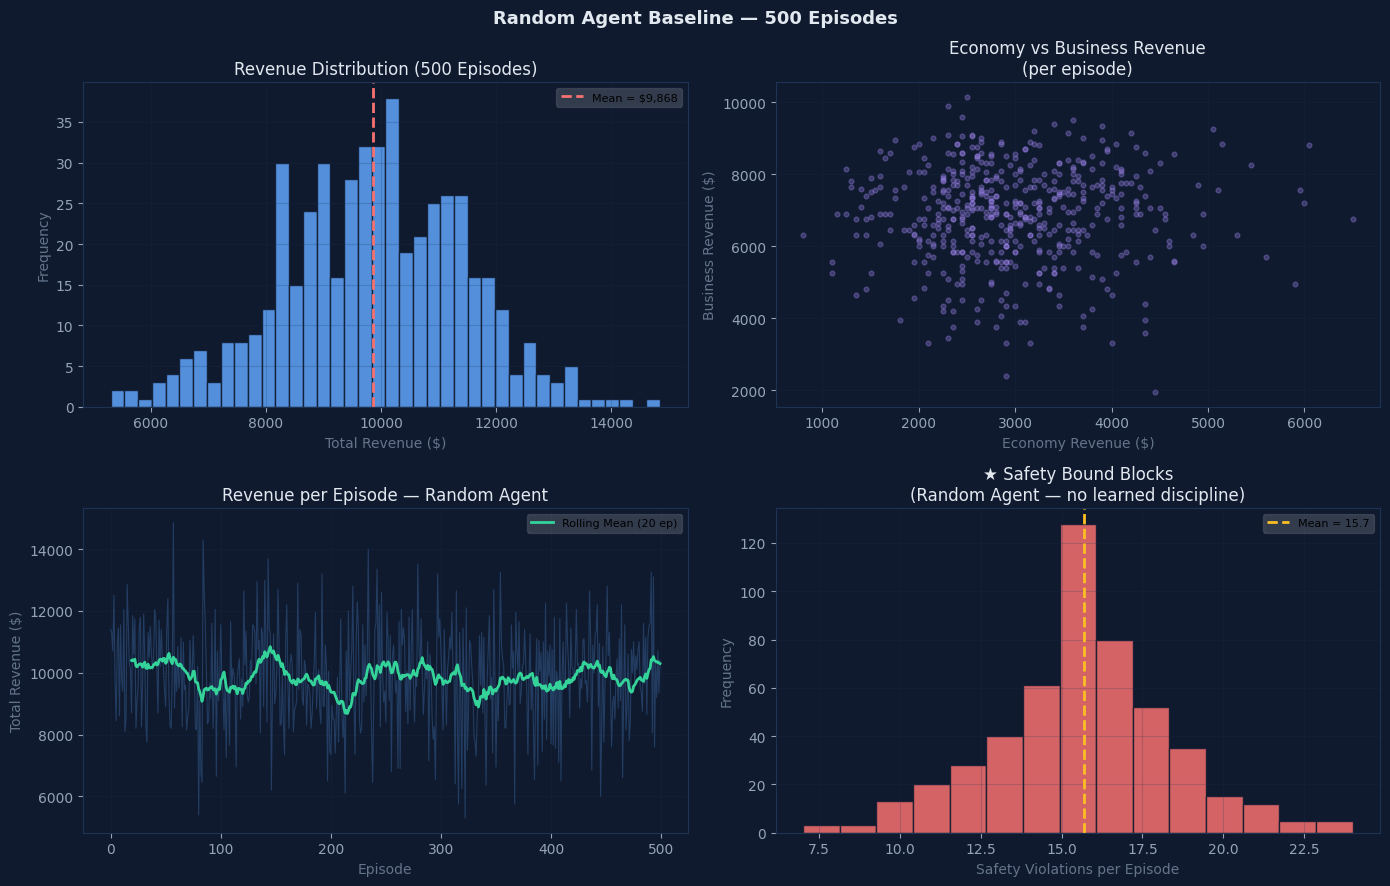

✅ Saved → reports/random_baseline.png


In [19]:
# ── CELL 12: Visualise Baseline Results ──────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9))
fig2.patch.set_facecolor('#0f1a2e')
for ax in axes2.flatten():
    ax.set_facecolor('#0f1a2e')
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3254')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#64748b')
    ax.yaxis.label.set_color('#64748b')
    ax.title.set_color('#e2e8f0')
 
axes2[0,0].hist(revenues, bins=40, color='#60a5fa', edgecolor='#0f1a2e', alpha=0.85)
axes2[0,0].axvline(np.mean(revenues), color='#f87171', linestyle='--',
                   linewidth=2, label=f'Mean = ${np.mean(revenues):,.0f}')
axes2[0,0].set_xlabel('Total Revenue ($)'); axes2[0,0].set_ylabel('Frequency')
axes2[0,0].set_title('Revenue Distribution (500 Episodes)')
axes2[0,0].legend(fontsize=8, framealpha=0.15)
axes2[0,0].grid(alpha=0.2, color='#1e3254')
 
axes2[0,1].scatter(eco_revs, biz_revs, alpha=0.3, color='#a78bfa', s=12)
axes2[0,1].set_xlabel('Economy Revenue ($)'); axes2[0,1].set_ylabel('Business Revenue ($)')
axes2[0,1].set_title('Economy vs Business Revenue\n(per episode)')
axes2[0,1].grid(alpha=0.2, color='#1e3254')
 
rolling = pd.Series(revenues).rolling(20).mean()
axes2[1,0].plot(revenues, color='#60a5fa', alpha=0.25, linewidth=0.8)
axes2[1,0].plot(rolling, color='#34d399', linewidth=2, label='Rolling Mean (20 ep)')
axes2[1,0].set_xlabel('Episode'); axes2[1,0].set_ylabel('Total Revenue ($)')
axes2[1,0].set_title('Revenue per Episode — Random Agent')
axes2[1,0].legend(fontsize=8, framealpha=0.15)
axes2[1,0].grid(alpha=0.2, color='#1e3254')
 
axes2[1,1].hist(violations_per_ep, bins=15, color='#f87171',
                edgecolor='#0f1a2e', alpha=0.85)
axes2[1,1].axvline(np.mean(violations_per_ep), color='#fbbf24', linestyle='--',
                   linewidth=2, label=f'Mean = {np.mean(violations_per_ep):.1f}')
axes2[1,1].set_xlabel('Safety Violations per Episode')
axes2[1,1].set_ylabel('Frequency')
axes2[1,1].set_title('★ Safety Bound Blocks\n(Random Agent — no learned discipline)')
axes2[1,1].legend(fontsize=8, framealpha=0.15)
axes2[1,1].grid(alpha=0.2, color='#1e3254')
 
plt.suptitle('Random Agent Baseline — 500 Episodes',
             fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.savefig('../reports/random_baseline.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/random_baseline.png")
 

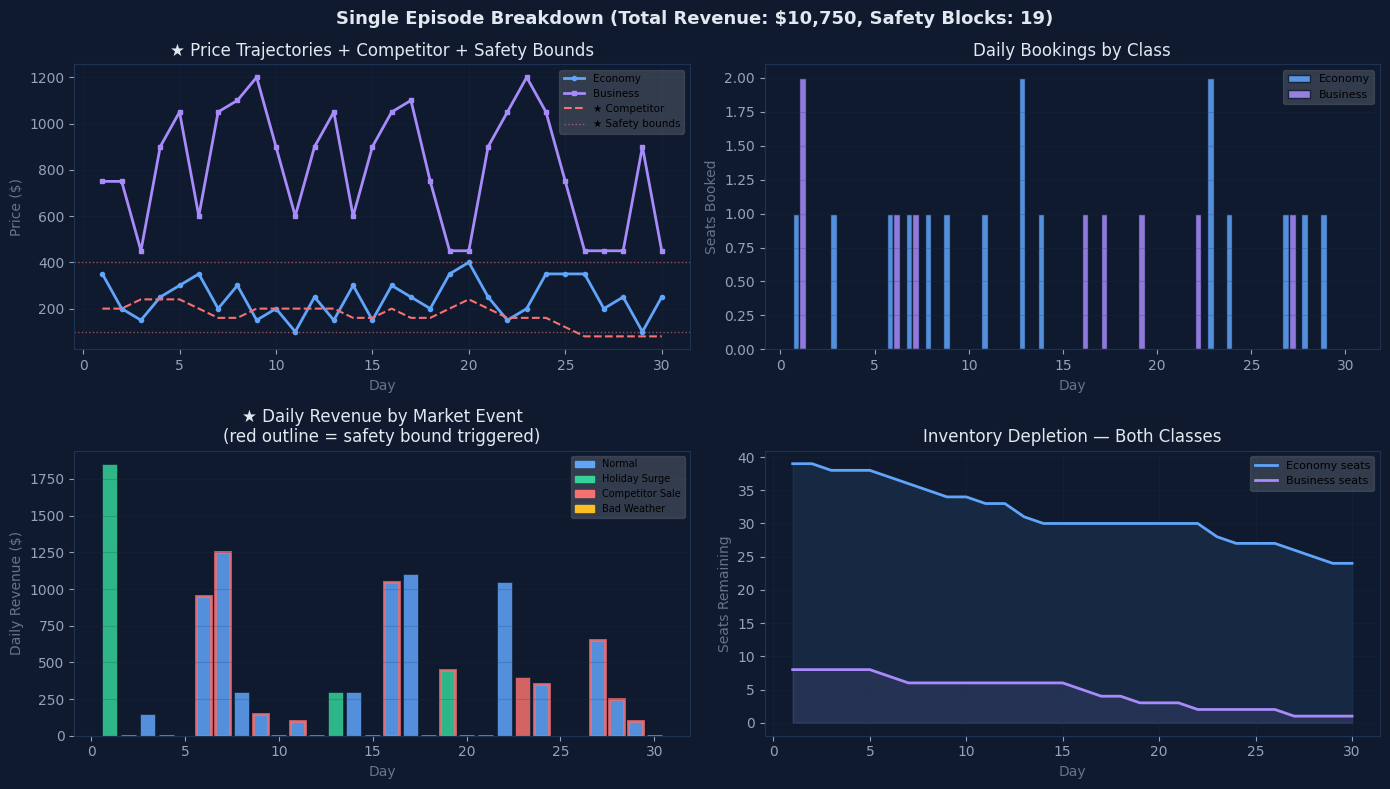

✅ Saved → reports/episode_breakdown.png


In [20]:
# ── CELL 13: Visualise One Episode in Detail ─────────────
env_d  = ContextualAirlinePricingEnv()
obs, _ = env_d.reset(seed=99)
done   = False
while not done:
    obs, _, done, _, _ = env_d.step(env_d.action_space.sample())
 
hist = env_d.get_history_df()
 
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 8))
fig3.patch.set_facecolor('#0f1a2e')
for ax in axes3.flatten():
    ax.set_facecolor('#0f1a2e')
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3254')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#64748b')
    ax.yaxis.label.set_color('#64748b')
    ax.title.set_color('#e2e8f0')
 
axes3[0,0].plot(hist['day'], hist['eco_price'], color='#60a5fa',
                linewidth=2, marker='o', markersize=3, label='Economy')
axes3[0,0].plot(hist['day'], hist['biz_price'], color='#a78bfa',
                linewidth=2, marker='s', markersize=3, label='Business')
axes3[0,0].plot(hist['day'], hist['competitor_price'], color='#f87171',
                linewidth=1.5, linestyle='--', label='★ Competitor')
axes3[0,0].axhline(ContextualAirlinePricingEnv.ECO_PRICES[SAFETY_CONFIG['eco_ceiling_idx']],
                   color='#f87171', linestyle=':', linewidth=1, alpha=0.6)
axes3[0,0].axhline(ContextualAirlinePricingEnv.ECO_PRICES[SAFETY_CONFIG['eco_floor_idx']],
                   color='#f87171', linestyle=':', linewidth=1, alpha=0.6,
                   label='★ Safety bounds')
axes3[0,0].set_xlabel('Day'); axes3[0,0].set_ylabel('Price ($)')
axes3[0,0].set_title('★ Price Trajectories + Competitor + Safety Bounds')
axes3[0,0].legend(fontsize=7.5, framealpha=0.15)
axes3[0,0].grid(alpha=0.2, color='#1e3254')
 
w = 0.35
axes3[0,1].bar(hist['day']-w/2, hist['eco_bookings'], width=w,
               color='#60a5fa', alpha=0.85, label='Economy', edgecolor='#0f1a2e')
axes3[0,1].bar(hist['day']+w/2, hist['biz_bookings'], width=w,
               color='#a78bfa', alpha=0.85, label='Business', edgecolor='#0f1a2e')
axes3[0,1].set_xlabel('Day'); axes3[0,1].set_ylabel('Seats Booked')
axes3[0,1].set_title('Daily Bookings by Class')
axes3[0,1].legend(fontsize=8, framealpha=0.15)
axes3[0,1].grid(alpha=0.2, color='#1e3254', axis='y')
 
for i, row in hist.iterrows():
    ev_key = next(k for k,v in MARKET_EVENTS.items() if v['name']==row['market_event'])
    col = MARKET_EVENTS[ev_key]['color']
    edge = '#f87171' if row['safety_violated'] else '#0f1a2e'
    lw   = 2 if row['safety_violated'] else 0.5
    axes3[1,0].bar(row['day'], row['daily_revenue'], color=col,
                   alpha=0.85, edgecolor=edge, linewidth=lw)
axes3[1,0].set_xlabel('Day'); axes3[1,0].set_ylabel('Daily Revenue ($)')
axes3[1,0].set_title('★ Daily Revenue by Market Event\n(red outline = safety bound triggered)')
legend_ev = [mpatches.Patch(color=MARKET_EVENTS[k]['color'],
             label=MARKET_EVENTS[k]['name']) for k in MARKET_EVENTS]
axes3[1,0].legend(handles=legend_ev, fontsize=7, framealpha=0.15)
axes3[1,0].grid(alpha=0.2, color='#1e3254', axis='y')
 
axes3[1,1].plot(hist['day'], hist['eco_seats_left'], color='#60a5fa',
                linewidth=2, label='Economy seats')
axes3[1,1].plot(hist['day'], hist['biz_seats_left'], color='#a78bfa',
                linewidth=2, label='Business seats')
axes3[1,1].fill_between(hist['day'], hist['eco_seats_left'], alpha=0.1, color='#60a5fa')
axes3[1,1].fill_between(hist['day'], hist['biz_seats_left'], alpha=0.1, color='#a78bfa')
axes3[1,1].set_xlabel('Day'); axes3[1,1].set_ylabel('Seats Remaining')
axes3[1,1].set_title('Inventory Depletion — Both Classes')
axes3[1,1].legend(fontsize=8, framealpha=0.15)
axes3[1,1].grid(alpha=0.2, color='#1e3254')
 
plt.suptitle(f'Single Episode Breakdown (Total Revenue: ${env_d.total_revenue:,.0f}, '
             f'Safety Blocks: {env_d.safety_violations})',
             fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.savefig('../reports/episode_breakdown.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/episode_breakdown.png")
 

In [21]:
# ── CELL 14: Save Baseline & Environment Config ──────────
baseline = {
    'mean_revenue'      : round(np.mean(revenues),  2),
    'std_revenue'       : round(np.std(revenues),   2),
    'min_revenue'       : round(np.min(revenues),   2),
    'max_revenue'       : round(np.max(revenues),   2),
    'mean_eco_revenue'  : round(np.mean(eco_revs),  2),
    'mean_biz_revenue'  : round(np.mean(biz_revs),  2),
    'mean_eco_sold'     : round(np.mean(eco_sold),  2),
    'mean_biz_sold'     : round(np.mean(biz_sold),  2),
    'mean_safety_blocks': round(np.mean(violations_per_ep), 2),
    'episodes'          : 500
}
pd.DataFrame([baseline]).to_csv('../data/week1_random_baseline.csv', index=False)
 
print("✅ Saved → data/week1_random_baseline.csv")
print()
print("=" * 62)
print("        WEEK 1 COMPLETE — SUMMARY")
print("=" * 62)
print("  ✅ Enhanced MDP formally defined (5D state space)")
print("  ✅ ContextualAirlinePricingEnv built & validated")
print("  ✅ Safety Bounds tested and verified working")
print()
print("  ★ UNIQUE FEATURES IMPLEMENTED:")
print("     1. Market Events        — 4 types, stochastic daily sampling")
print("     2. 3 Customer Segments  — business / leisure / last-minute")
print("     3. Competitor Price     — drives agent's pricing reaction")
print("     4. Dual Class Inventory — Economy (40) + Business (10)")
print("     5. Safety Bounds        — floor/ceiling + max daily swing,")
print("                               matches the project's Revenue")
print("                               Manager safety requirement")
print()
print(f"  Baseline (random agent, 500 eps):")
print(f"     Mean Revenue     : ${np.mean(revenues):,.0f}")
print(f"     Eco / Biz split  : ${np.mean(eco_revs):,.0f} / ${np.mean(biz_revs):,.0f}")
print(f"     Mean Safety Blocks: {np.mean(violations_per_ep):.1f} per episode")
print()
print("  Reports generated:")
print("     ✅ demand_function.png")
print("     ✅ random_baseline.png")
print("     ✅ episode_breakdown.png")
print()
print("  Ready for Week 2 — EMSR Baseline + Q-Learning ✅")
print("=" * 62)
 

✅ Saved → data/week1_random_baseline.csv

        WEEK 1 COMPLETE — SUMMARY
  ✅ Enhanced MDP formally defined (5D state space)
  ✅ ContextualAirlinePricingEnv built & validated
  ✅ Safety Bounds tested and verified working

  ★ UNIQUE FEATURES IMPLEMENTED:
     1. Market Events        — 4 types, stochastic daily sampling
     2. 3 Customer Segments  — business / leisure / last-minute
     3. Competitor Price     — drives agent's pricing reaction
     4. Dual Class Inventory — Economy (40) + Business (10)
     5. Safety Bounds        — floor/ceiling + max daily swing,
                               matches the project's Revenue
                               Manager safety requirement

  Baseline (random agent, 500 eps):
     Mean Revenue     : $9,868
     Eco / Biz split  : $2,987 / $6,881
     Mean Safety Blocks: 15.7 per episode

  Reports generated:
     ✅ demand_function.png
     ✅ random_baseline.png
     ✅ episode_breakdown.png

  Ready for Week 2 — EMSR Baseline + Q-Learning ✅
